<a href="https://colab.research.google.com/github/adityab-tech/PRISMx/blob/main/notebooks/03_Market_Conditioned_Gating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PRISM - Deliverable 3 — Market-Conditioned Gating Head
###Objectives

- Load Fine-Tuned Kronos Encoder (LoRA/QLoRA)
- Prepare Market Index Embeddings (NIFTY 50, NIFTY 500, Sector Indices)
- Implement Cross-Attention Module
- Build Market-Conditioned Gating Head
- Fuse Stock & Market Representations
- Train Only Gating Head + LoRA Adapters (Freeze Kronos Backbone)
- Evaluate Gated vs. Ungated Models
--Perform Conditioning Signal Ablation (NIFTY 50 vs. Sector Indices)
- Save Best Market-Gated Model

#Prepare Inputs

In [1]:
import os
import sys
import yaml
import random
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
!git clone https://github.com/shiyu-coder/Kronos.git

Cloning into 'Kronos'...
remote: Enumerating objects: 371, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 371 (delta 66), reused 49 (delta 49), pack-reused 269 (from 1)
Receiving objects: 100% (371/371), 9.30 MiB | 15.72 MiB/s, done.
Resolving deltas: 100% (178/178), done.


In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
!pip -q install transformers peft

In [5]:
sys.path.append("/content/Kronos")
sys.path.append("/content/Kronos/finetune_csv")

In [6]:
from peft import LoraConfig, get_peft_model
from model import Kronos ,KronosTokenizer

In [7]:
PROJECT_ROOT = "/content/drive/MyDrive/PRISM"
TOKENIZER_PATH = f"{PROJECT_ROOT}/models/kronos/tokenizer/best_model"
KRONOS_PATH = f"{PROJECT_ROOT}/models/kronos/basemodel/best_model"
DATASET_PATH = f"{PROJECT_ROOT}/datasets"
LORA_PATH = f"{PROJECT_ROOT}/models/kronos/lora"
RESULTS_PATH = f"{PROJECT_ROOT}/results/del3"
os.makedirs(RESULTS_PATH, exist_ok=True)

In [8]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [9]:
from peft import PeftModel

# Load Tokenizer (same as before)
tokenizer = KronosTokenizer.from_pretrained(TOKENIZER_PATH, local_files_only=True)
tokenizer.eval()
print("Tokenizer Loaded")

# Load base (fully fine-tuned) Kronos
base_model = Kronos.from_pretrained(KRONOS_PATH, local_files_only=True)
print("Base Kronos Loaded")

# Freeze tokenizer
for param in tokenizer.parameters():
    param.requires_grad = False

# Freeze base backbone
for param in base_model.parameters():
    param.requires_grad = False

# Reload the trained LoRA adapters
model = PeftModel.from_pretrained(base_model, LORA_PATH)
model.eval()
print("Trained LoRA adapters loaded")

model.print_trainable_parameters()

Loading weights from local directory
Tokenizer Loaded
Loading weights from local directory
Base Kronos Loaded


Trained LoRA adapters loaded
trainable params: 0 || all params: 103,695,040 || trainable%: 0.0000


In [10]:
print(type(tokenizer))
print(type(model))

<class 'model.kronos.KronosTokenizer'>
<class 'peft.peft_model.PeftModel'>


In [11]:
for name, param in model.named_parameters():
    if "lora_" in name:
        param.requires_grad = True

In [12]:
model.print_trainable_parameters()

trainable params: 1,384,448 || all params: 103,695,040 || trainable%: 1.3351


In [13]:
#Ye code model ke saare parameters me se sirf LoRA adapter layers ke names dhoondhkar ek list me store karta hai.
lora_layers = []
for name, _ in model.named_parameters():
    if "lora_" in name:
        lora_layers.append(name)

print("Total LoRA tensors :", len(lora_layers))
print(lora_layers[:10])

Total LoRA tensors : 104
['base_model.model.transformer.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.transformer.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.transformer.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.transformer.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.transformer.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.transformer.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.transformer.0.self_attn.out_proj.lora_A.default.weight', 'base_model.model.transformer.0.self_attn.out_proj.lora_B.default.weight', 'base_model.model.transformer.1.self_attn.q_proj.lora_A.default.weight', 'base_model.model.transformer.1.self_attn.q_proj.lora_B.default.weight']


In [14]:
market_df = pd.read_csv("/content/drive/MyDrive/PRISM/data/raw/NIFTY50.csv")
market_df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2019-01-02,10792.500000,10792.500000,10895.349609,10735.049805,10868.849609,309700
1,2019-01-03,10672.250000,10672.250000,10814.049805,10661.250000,10796.799805,286200
2,2019-01-04,10727.349609,10727.349609,10741.049805,10628.650391,10699.700195,296600
3,2019-01-07,10771.799805,10771.799805,10835.950195,10750.150391,10804.849609,269400
4,2019-01-08,10802.150391,10802.150391,10818.450195,10733.250000,10786.250000,277700


In [15]:
FEATURES = ["Close","Volume","Open","High","Low"]
market_features = market_df[FEATURES]

In [16]:
market_tensor = torch.tensor(market_features.values,dtype=torch.float32)
print(market_tensor.shape)

torch.Size([1478, 5])


In [17]:
#market time-series data ko 36-step overlapping sequences me convert karta hai, jise model training/inference ke input ke roop me use kiya ja sake
SEQ_LEN = 36
market_sequences = []
for i in range(len(market_tensor) - SEQ_LEN):
    market_sequences.append( market_tensor[i:i+SEQ_LEN])

market_sequences = torch.stack(market_sequences)
print(market_sequences.shape)

torch.Size([1442, 36, 5])


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


#Cross-Attention

In [19]:
#Ye wrapper class Kronos ko encoder ki tarah use karke input stock tokens se contextual(stock) embeddings bana raha hai
class StockEncoder(nn.Module):

    def __init__(self, kronos):                       #Constructor me pretrained Kronos model receive kar raha hai
        super().__init__()
        self.kronos = kronos

    def forward(self,s1_ids,s2_ids,stamp=None,padding_mask=None):         #Forward pass me token IDs aur timestamps input ke roop me leta hai
        # Kronos already provides transformer context
        _, context = self.kronos.decode_s1(s1_ids,s2_ids,stamp,padding_mask) #Kronos Transformer se context embeddings nikal raha hai; pehla output ignore karke sirf context use kar raha hai

        return context

In [20]:
#kronos ko StockEncoder bana kar evaluation mode me ready karta hai taaki stock sequences ke contextual embeddings extract kiye ja sake
stock_encoder = StockEncoder(model).to(device)
stock_encoder.eval()

StockEncoder(
  (kronos): PeftModel(
    (base_model): LoraModel(
      (model): Kronos(
        (token_drop): Dropout(p=0.0, inplace=False)
        (embedding): HierarchicalEmbedding(
          (emb_s1): Embedding(1024, 832)
          (emb_s2): Embedding(1024, 832)
          (fusion_proj): Linear(in_features=1664, out_features=832, bias=True)
        )
        (time_emb): TemporalEmbedding(
          (minute_embed): Embedding(60, 832)
          (hour_embed): Embedding(24, 832)
          (weekday_embed): Embedding(7, 832)
          (day_embed): Embedding(32, 832)
          (month_embed): Embedding(13, 832)
        )
        (transformer): ModuleList(
          (0-11): 12 x TransformerBlock(
            (norm1): RMSNorm()
            (self_attn): MultiHeadAttentionWithRoPE(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=832, out_features=832, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace

In [21]:
#yeh code toh bus dummy hai to check if stock embeddings kaam kar rahi hai ya nahi
with torch.no_grad():
#(2,36) ka matlab hai 2 sequences generate karo aur har sequence me 36 token IDs hai
    dummy_s1 = torch.randint(0,model.s1_vocab_size,(2,36)).to(device)  #S1 vocabulary(S1 tokenizer jitne unique token IDs bana sakta hai, un sabka collection) ke valid token IDs ke andar hi random numbers generate karta hai
    dummy_s2 = torch.randint(0,model.s2_bits**2,(2,36)).to(device)     #Kronos me S2 tokens ek quantized codebook se aate hain
    context = stock_encoder(dummy_s1,dummy_s2)                         #Random tokens ko StockEncoder me pass karke context embeddings nikal raha hai.

print(context.shape)

torch.Size([2, 36, 832])


In [22]:
#Ye har day ke embedding me uski position add kar deta hai kyuki everyday ki info alag alag matter karti hai
class PositionalEncoding(nn.Module):                     #Transformer ke liye positional encoding layer bana rahe hain

    def __init__(self, d_model, max_len=5000):           #constructor hai jo maximum 5000 positions ke liye positional encodings banata hai
        super().__init__()                               # d model is Embedding dimension --Matlab ek token ko represent karne ke liye kitne numbers use honge.
        pe = torch.zeros(max_len, d_model)               #Ek matrix banata hai jisme baad me har position ka encoding store hoga
        position = torch.arange(0, max_len).unsqueeze(1) #Har position ka index banata hai.

        div_term = torch.exp(                            #Different freq generate karta hai jisse har embedding dimension alag sinusoidal pattern follow kare
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model))

        pe[:,0::2] = torch.sin(position * div_term)      #Even dimensions me sine values fill karta hai
        pe[:,1::2] = torch.cos(position * div_term)      #odd dimensions me cosine values fill karta hai
        pe = pe.unsqueeze(0)                             #Batch dimension add karta hai
        self.register_buffer("pe", pe)                   #Positional encoding ko model me permanently store karta hai, lekin ye trainable parameter nahi hota

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]                #Embedding + Position Information

In [23]:
hidden_dim = model.d_model      #Market encoder ka embedding size Kronos ke embedding size ke barabar rakha hai
n_heads = model.n_heads         #Market encoder me bhi Kronos jitne attention heads use kar rahe hain
class MarketEncoder(nn.Module):
  def __init__(self,input_dim=3,hidden_dim=hidden_dim,num_layers=2,n_heads=n_heads,dropout=0.1):
        super().__init__()         #Transformer Encoder ke 2 layers use honge and Input me har time step par 5 market features aayengi

        # Project OHLCV -> hidden space
        self.input_proj = nn.Linear(input_dim,hidden_dim)      #Transformer directly 5 features par kaam nahi karega.Usse Kronos jaisa embedding size chahiye
        self.pos_encoding = PositionalEncoding(hidden_dim)     #Har day ki position embedding me add karta hai

        # Single lightweight attention layer
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(hidden_dim)

        # Much smaller FFN
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim)
        )

        self.norm2 = nn.LayerNorm(hidden_dim)

  def forward(self, x):

        x = self.input_proj(x)
        x = self.pos_encoding(x)
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)
        ff = self.ffn(x)
        x = self.norm2(x + ff)

        return x

In [24]:
market_encoder = MarketEncoder().to(device)
print(market_encoder)

MarketEncoder(
  (input_proj): Linear(in_features=3, out_features=832, bias=True)
  (pos_encoding): PositionalEncoding()
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=832, out_features=832, bias=True)
  )
  (norm1): LayerNorm((832,), eps=1e-05, elementwise_affine=True)
  (ffn): Sequential(
    (0): Linear(in_features=832, out_features=1664, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1664, out_features=832, bias=True)
  )
  (norm2): LayerNorm((832,), eps=1e-05, elementwise_affine=True)
)


In [25]:
dummy_market = torch.randn(32,36,3).to(device)
market_embedding = market_encoder(dummy_market)

print(market_embedding.shape)

torch.Size([32, 36, 832])


In [26]:
class MarketCrossAttention(nn.Module):

    """
    Stock tokens attend over Market embeddings.
    Query  -> Stock Representation
    Key    -> Market Representation
    Value  -> Market Representation
    """
    def __init__(self,d_model,n_heads,dropout=0.1):
        super().__init__()

        self.cross_attention = nn.MultiheadAttention(embed_dim=d_model,num_heads=n_heads,dropout=dropout,batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(nn.Linear(d_model, d_model * 4), nn.GELU(),nn.Dropout(dropout),nn.Linear(d_model * 4, d_model))
        self.dropout = nn.Dropout(dropout)

    def forward(self,stock_features,market_features,market_padding_mask=None):
        residual = stock_features

        attended_features, attention_weights = self.cross_attention(

            query=stock_features,
            key=market_features,
            value=market_features,
            key_padding_mask=market_padding_mask,
            need_weights=True)

        x = self.norm1(residual +self.dropout(attended_features))
        ff = self.ffn(x)
        x = self.norm2(x+ self.dropout(ff))
        return x, attention_weights

In [27]:
cross_attention = MarketCrossAttention(d_model=model.d_model,n_heads=model.n_heads,dropout=0.1
).to(device)

In [28]:
dummy_stock = torch.randn(32,36,model.d_model
).to(device)

dummy_market = torch.randn(32,36,model.d_model
).to(device)

cross_output, attention = cross_attention(dummy_stock,dummy_market)

print("Output :", cross_output.shape)
print("Attention :", attention.shape)

Output : torch.Size([32, 36, 832])
Attention : torch.Size([32, 36, 36])


#Gating

In [29]:
class MasterGate(nn.Module):

    def __init__(self, d_model, dropout=0.1):
        super().__init__()

        self.stock_proj = nn.Linear(d_model,d_model)
        self.market_proj = nn.Linear(d_model,d_model)
        self.gate = nn.Sequential(

            nn.Linear(d_model*2,d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model,d_model),
            nn.Sigmoid())

        self.norm = nn.LayerNorm(d_model)

    def forward(self,stock_features,market_features):

        stock = self.stock_proj(stock_features)
        market = self.market_proj(market_features)
        gate = self.gate(torch.cat([stock, market],dim=-1))

        delta = stock - market
        fused = (stock + gate * delta)

        fused = self.norm(fused)
        return fused, gate

In [30]:
gate_head = MasterGate(
    d_model=model.d_model
).to(device)

In [31]:
dummy_stock = torch.randn(
    32,
    36,
    model.d_model
).to(device)

dummy_market = torch.randn(
    32,
    36,
    model.d_model
).to(device)

fused, gate = gate_head(
    dummy_stock,
    dummy_market
)

print("Fused :", fused.shape)

print("Gate :", gate.shape)

print(
    gate.min().item(),
    gate.max().item()
)

Fused : torch.Size([32, 36, 832])
Gate : torch.Size([32, 36, 832])
0.36430010199546814 0.6371618509292603


In [32]:
# Prediction Head
class ReturnPredictionHead(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.mlp = nn.Sequential(

            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, d_model // 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 4, 1))

    def forward(self, x):

        # Convert to (B, D, T) for pooling
        x = x.transpose(1, 2)

        # Global temporal pooling -> (B, D, 1)
        x = self.pool(x)

        # Remove last dimension -> (B, D)
        x = x.squeeze(-1)

        # Predict scalar return
        out = self.mlp(x)

        return out

# Full Market-Conditioned Model


class MarketConditionedKronos(nn.Module):

    def __init__(self,tokenizer,kronos_model,stock_encoder,
        market_encoder,cross_attention,gate_head):

        super().__init__()
        self.tokenizer = tokenizer
        self.kronos_model = kronos_model
        self.stock_encoder = stock_encoder
        self.market_encoder = market_encoder
        self.cross_attention = cross_attention
        self.gate_head = gate_head

        self.prediction_head = ReturnPredictionHead(
            d_model=kronos_model.d_model)

    def forward(

        self,

        stock_ohlcv,
        market_ohlcv,
        stamp=None

    ):

        # Step 1 : Tokenize stock sequence using Kronos

        with torch.no_grad():

            s1_ids, s2_ids = self.tokenizer.encode(
                stock_ohlcv,
                half=True
            )


        # Step 2 : Extract stock representations

        stock_features = self.stock_encoder(
            s1_ids,
            s2_ids,
            stamp
        )

        # Step 3 : Encode market sequence

        market_features = self.market_encoder(
            market_ohlcv
        )
        # Step 4 : Market cross-attention
        market_conditioned, attention_weights = self.cross_attention(
            stock_features,
            market_features
        )

        # Step 5 : Adaptive MASTER gate
        fused_features, gate_values = self.gate_head(
            stock_features,
            market_conditioned
        )

        # Step 6 : Predict next-period return

        prediction = self.prediction_head(
            fused_features
        )

        return {
            'prediction': prediction,
            'stock_features': stock_features,
            'market_features': market_features,
            'market_conditioned': market_conditioned,
            'fused_features': fused_features,
            'attention_weights': attention_weights,
            'gate_values': gate_values
        }

# Instantiate the full model

full_model = MarketConditionedKronos(
    tokenizer=tokenizer,
    kronos_model=model,
    stock_encoder=stock_encoder,
    market_encoder=market_encoder,
    cross_attention=cross_attention,
    gate_head=gate_head
).to(device)

print(full_model)

MarketConditionedKronos(
  (tokenizer): KronosTokenizer(
    (embed): Linear(in_features=6, out_features=256, bias=True)
    (head): Linear(in_features=256, out_features=6, bias=True)
    (encoder): ModuleList(
      (0-2): 3 x TransformerBlock(
        (norm1): RMSNorm()
        (self_attn): MultiHeadAttentionWithRoPE(
          (q_proj): Linear(in_features=256, out_features=256, bias=True)
          (k_proj): Linear(in_features=256, out_features=256, bias=True)
          (v_proj): Linear(in_features=256, out_features=256, bias=True)
          (out_proj): Linear(in_features=256, out_features=256, bias=True)
          (rotary): RotaryPositionalEmbedding()
          (resid_dropout): Dropout(p=0.0, inplace=False)
        )
        (norm2): RMSNorm()
        (ffn): FeedForward(
          (w1): Linear(in_features=256, out_features=512, bias=False)
          (w3): Linear(in_features=256, out_features=512, bias=False)
          (w2): Linear(in_features=512, out_features=256, bias=False)
    

In [33]:
dummy_stock = torch.randn(
    8, 36, 6).to(device)
dummy_market = torch.randn(
    8, 36, 3).to(device)

# Forward pass

with torch.no_grad():

    outputs = full_model(
        stock_ohlcv=dummy_stock,
        market_ohlcv=dummy_market,
        stamp=None
    )

# Check shapes

for key, value in outputs.items():

    print(f'{key:20s} : {tuple(value.shape)}')

prediction           : (8, 1)
stock_features       : (8, 36, 832)
market_features      : (8, 36, 832)
market_conditioned   : (8, 36, 832)
fused_features       : (8, 36, 832)
attention_weights    : (8, 36, 36)
gate_values          : (8, 36, 832)


In [34]:
# Count trainable parameters
trainable = 0
frozen = 0

for name, param in full_model.named_parameters():

    if param.requires_grad:
        trainable += param.numel()
    else:
        frozen += param.numel()

print(f'Trainable Parameters : {trainable:,}')
print(f'Frozen Parameters    : {frozen:,}')
print(f'Trainable %           : {100 * trainable / (trainable + frozen):.2f}%')

Trainable Parameters : 19,151,809
Frozen Parameters    : 106,268,634
Trainable %           : 15.27%


In [35]:
trainable_summary = {}

for name, param in full_model.named_parameters():
    if param.requires_grad:
        module = name.split('.')[0]
        trainable_summary[module] = (
            trainable_summary.get(module, 0) + param.numel()
        )

for k, v in trainable_summary.items():
    print(f'{k:20s} : {v:,}')

kronos_model         : 1,384,448
market_encoder       : 5,550,272
cross_attention      : 8,317,504
gate_head            : 3,466,112
prediction_head      : 433,473


#Training Loop

In [36]:
STOCK_PATH = "/content/drive/MyDrive/PRISM/data/processed/RELIANCE.NS.csv"
stock_df = pd.read_csv(STOCK_PATH)
print(stock_df.shape)
stock_df.head()

(1118, 16)


,Date,Close,High,Low,Open,Volume,Return,Log_Return,MA5,MA10,MA20,EMA20,Volatility,Volume_Change,Volume_MA20,Beta
0,2020-03-27,474.505524,493.074299,465.866824,487.597187,41657940,-0.000563,-0.000563,448.990179,443.929416,496.833708,495.441343,0.069612,-0.089334,47997996.65,1.236910
1,2020-03-30,458.853424,478.602224,454.200113,463.373180,30229866,-0.032986,-0.033542,462.028387,444.586221,490.194370,491.956779,0.069439,-0.274331,47543701.50,1.221455
2,2020-03-31,495.946472,503.093419,466.668378,478.223761,44292810,0.080839,0.077737,477.199561,449.295203,485.687991,492.336750,0.072373,0.465200,48283317.25,1.247226
3,2020-04-01,481.118164,500.777879,465.421544,499.731437,41597459,-0.029899,-0.030355,477.039258,454.280273,479.845731,491.268313,0.072290,-0.060853,48993250.30,1.235940
4,2020-04-03,479.782257,505.164047,470.364285,505.164047,41367807,-0.002777,-0.002781,478.041168,461.393848,474.006810,490.174403,0.072288,-0.005521,49956377.60,1.229398


In [37]:
# Configuration
SEQ_LEN = 36
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4

# --- Feature engineering ---
stock_df['Return'] = stock_df['Close'].pct_change()
stock_df['Volatility_5'] = stock_df['Return'].rolling(5).std()
stock_df['Momentum_5'] = stock_df['Close'].pct_change(5)

market_df['Return'] = market_df['Close'].pct_change()
market_df['Volatility_5'] = market_df['Return'].rolling(5).std()
market_df['Momentum_5'] = market_df['Close'].pct_change(5)

stock_df = stock_df.dropna().reset_index(drop=True)
market_df = market_df.dropna().reset_index(drop=True)

STOCK_FEATURES = ['Open','High','Low','Close','Volume','Return']
MARKET_FEATURES = ['Return','Volatility_5','Momentum_5']

stock_df['target_return'] = (
    stock_df['Close'].shift(-1) - stock_df['Close']
) / stock_df['Close']
TARGET_COL = 'target_return'

stock_values = stock_df[STOCK_FEATURES].values.astype(np.float32)
market_values = market_df[MARKET_FEATURES].values.astype(np.float32)
targets = stock_df[TARGET_COL].values.astype(np.float32)

# --- Scale features (fit only on train portion, chronologically) ---
split_idx = int(len(stock_values) * 0.8)

stock_scaler = StandardScaler().fit(stock_values[:split_idx])
market_scaler = StandardScaler().fit(market_values[:split_idx])

stock_values = stock_scaler.transform(stock_values)
market_values = market_scaler.transform(market_values)

# --- Build aligned sequences (same as before, now on scaled data) ---
stock_sequences, market_sequences, target_values = [], [], []
for i in range(len(stock_df) - SEQ_LEN - 1):
    target = targets[i+SEQ_LEN]
    if np.isnan(target):
        continue
    stock_sequences.append(stock_values[i:i+SEQ_LEN])
    market_sequences.append(market_values[i:i+SEQ_LEN])
    target_values.append(target)

stock_sequences = np.array(stock_sequences)
market_sequences = np.array(market_sequences)
target_values = np.array(target_values)

print('Stock sequences :', stock_sequences.shape)
print('Market sequences:', market_sequences.shape)

Stock sequences : (1076, 36, 6)
Market sequences: (1076, 36, 3)


In [38]:
# Train / Validation split
# IMPORTANT: shuffle=False for time-series
X_stock_train, X_stock_val, X_market_train, X_market_val, y_train, y_val = train_test_split(
    stock_sequences,
    market_sequences,
    target_values,
    test_size=0.2,
    shuffle=False
)

print('Train stock :', X_stock_train.shape)
print('Val stock   :', X_stock_val.shape)

Train stock : (860, 36, 6)
Val stock   : (216, 36, 6)


In [39]:
# Dataset

class MarketConditionedDataset(Dataset):

    def __init__(self, stock_x, market_x, y):

        self.stock_x = torch.tensor(stock_x, dtype=torch.float32)

        self.market_x = torch.tensor(market_x, dtype=torch.float32)

        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):

        return len(self.y)

    def __getitem__(self, idx):

        return (
            self.stock_x[idx],      # (36,6)
            self.market_x[idx],     # (36,5)
            self.y[idx]             # scalar
        )


# DataLoaders


train_dataset = MarketConditionedDataset(
    X_stock_train,
    X_market_train,
    y_train
)

val_dataset = MarketConditionedDataset(
    X_stock_val,
    X_market_val,
    y_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
print('Train batches :', len(train_loader))
print('Val batches   :', len(val_loader))


# Sanity check


stock_batch, market_batch, target_batch = next(iter(train_loader))

print('Stock batch  :', stock_batch.shape)
print('Market batch :', market_batch.shape)
print('Target batch :', target_batch.shape)


Train batches : 26
Val batches   : 7
Stock batch  : torch.Size([32, 36, 6])
Market batch : torch.Size([32, 36, 3])
Target batch : torch.Size([32])


In [40]:
# Optimizer and Loss

trainable_params = [
    p for p in full_model.parameters()
    if p.requires_grad
]

optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

def combined_loss(preds, targets, alpha=0.7):
    mse_loss = nn.functional.mse_loss(preds, targets)
    direction_loss = nn.functional.binary_cross_entropy_with_logits(
        preds, (targets > 0).float()
    )
    return alpha * mse_loss + (1 - alpha) * direction_loss

criterion = combined_loss

print(f'Trainable parameter tensors: {len(trainable_params)}')

Trainable parameter tensors: 146


In [41]:
# Training Function
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0.0

    for stock_batch, market_batch, target_batch in loader:
        stock_batch = stock_batch.to(device)
        market_batch = market_batch.to(device)
        target_batch = target_batch.to(device)

        # Forward pass

        outputs = model(
            stock_ohlcv=stock_batch,
            market_ohlcv=market_batch,
            stamp=None
        )

        preds = outputs['prediction'].squeeze(-1)
        loss = criterion(preds, target_batch)

        # Backward pass

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            trainable_params,
            max_norm=1.0
        )

        optimizer.step()
        running_loss += loss.item()

    return running_loss / len(loader)

In [42]:
# Validation Function
@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_targets = []

    for stock_batch, market_batch, target_batch in loader:

        stock_batch = stock_batch.to(device)

        market_batch = market_batch.to(device)

        target_batch = target_batch.to(device)

        outputs = model(
            stock_ohlcv=stock_batch,
            market_ohlcv=market_batch,
            stamp=None
        )

        preds = outputs['prediction'].squeeze(-1)

        loss = criterion(preds, target_batch)

        running_loss += loss.item()

        all_preds.append(preds.cpu())

        all_targets.append(target_batch.cpu())

    avg_loss = running_loss / len(loader)

    all_preds = torch.cat(all_preds)

    all_targets = torch.cat(all_targets)

    return avg_loss, all_preds, all_targets

In [43]:
# Main Training Loop

best_val_loss = float('inf')
patience = 3
patience_counter = 0
history = {
    'train_loss': [],
    'val_loss': []}

for epoch in range(EPOCHS):

    # ---------------- TRAIN ----------------
    train_loss = train_one_epoch(
        full_model,
        train_loader
    )

    # ---------------- VALIDATE ----------------
    val_loss, val_preds, val_targets = evaluate(
        full_model,
        val_loader
    )

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f'Epoch {epoch+1:02d}/{EPOCHS}')
    print(f'   Train Loss : {train_loss:.6f}')
    print(f'   Val Loss   : {val_loss:.6f}')

    # ---------------- SAVE BEST ----------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            full_model.state_dict(),
            f'{RESULTS_PATH}/best_market_conditioned_kronos.pt'
        )

        print('   Best model saved')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print('-' * 60)

Epoch 01/10
   Train Loss : 0.212822
   Val Loss   : 0.208122
   Best model saved
------------------------------------------------------------
Epoch 02/10
   Train Loss : 0.208610
   Val Loss   : 0.208140
------------------------------------------------------------
Epoch 03/10
   Train Loss : 0.208668
   Val Loss   : 0.208057
   Best model saved
------------------------------------------------------------
Epoch 04/10
   Train Loss : 0.208417
   Val Loss   : 0.208682
------------------------------------------------------------
Epoch 05/10
   Train Loss : 0.208411
   Val Loss   : 0.208196
------------------------------------------------------------
Epoch 06/10
   Train Loss : 0.208069
   Val Loss   : 0.208020
   Best model saved
------------------------------------------------------------
Epoch 07/10
   Train Loss : 0.208264
   Val Loss   : 0.208041
------------------------------------------------------------
Epoch 08/10
   Train Loss : 0.208422
   Val Loss   : 0.208953
-----------------

In [44]:
# Save LoRA Adapters

full_model.kronos_model.save_pretrained(
    f'{RESULTS_PATH}/lora_adapters')
print('LoRA adapters saved')

LoRA adapters saved


#Evaluation

In [45]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from scipy.stats import pearsonr, spearmanr

In [46]:
checkpoint_path = f'{RESULTS_PATH}/best_market_conditioned_kronos.pt'

full_model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)
full_model.eval()

print('Best model loaded')

Best model loaded


In [47]:
#validation prediction
val_loss, val_preds, val_targets = evaluate(full_model, val_loader)
preds = val_preds.numpy()
targets = val_targets.numpy()

print('Validation loss:', val_loss)
print('Predictions shape:', preds.shape)
print('Targets shape    :', targets.shape)

Validation loss: 0.2080195333276476
Predictions shape: (216,)
Targets shape    : (216,)


In [48]:
# Regression metrics
mae = mean_absolute_error(targets, preds)
rmse = np.sqrt(mean_squared_error(targets, preds))

# Avoid divide-by-zero
mape = np.mean(
    np.abs((targets - preds) / (targets + 1e-8))
) * 100

print(f'MAE  : {mae:.6f}')
print(f'RMSE : {rmse:.6f}')
print(f'MAPE : {mape:.2f}%')

MAE  : 0.010506
RMSE : 0.014443
MAPE : 177.11%


In [49]:
# Information Coefficient (Pearson)
ic, ic_p = pearsonr(targets, preds)

# Rank Information Coefficient (Spearman)
rank_ic, rank_p = spearmanr(targets, preds)

print(f'IC (Pearson)     : {ic:.4f}  (p={ic_p:.4g})')
print(f'Rank IC (Spearman): {rank_ic:.4f}  (p={rank_p:.4g})')

IC (Pearson)     : 0.0818  (p=0.2312)
Rank IC (Spearman): 0.0919  (p=0.1783)


In [50]:
pred_direction = np.sign(preds)
true_direction = np.sign(targets)

directional_accuracy = (
    pred_direction == true_direction
).mean() * 100

print(f'Directional Accuracy : {directional_accuracy:.2f}%')

Directional Accuracy : 52.78%


In [51]:
metrics_df = pd.DataFrame({
    'Metric': ['MAE','RMSE','MAPE','IC','Rank IC','Directional Accuracy'],
    'Value': [mae,rmse,mape,ic,rank_ic,directional_accuracy]
})
metrics_df

,Metric,Value
0,MAE,0.010506
1,RMSE,0.014443
2,MAPE,177.111420
3,IC,0.081808
4,Rank IC,0.091927
5,Directional Accuracy,52.777778


In [52]:
metrics_df.to_csv(
    f'{RESULTS_PATH}/del3_metrics.csv',
    index=False
)

print('Metrics saved')

Metrics saved


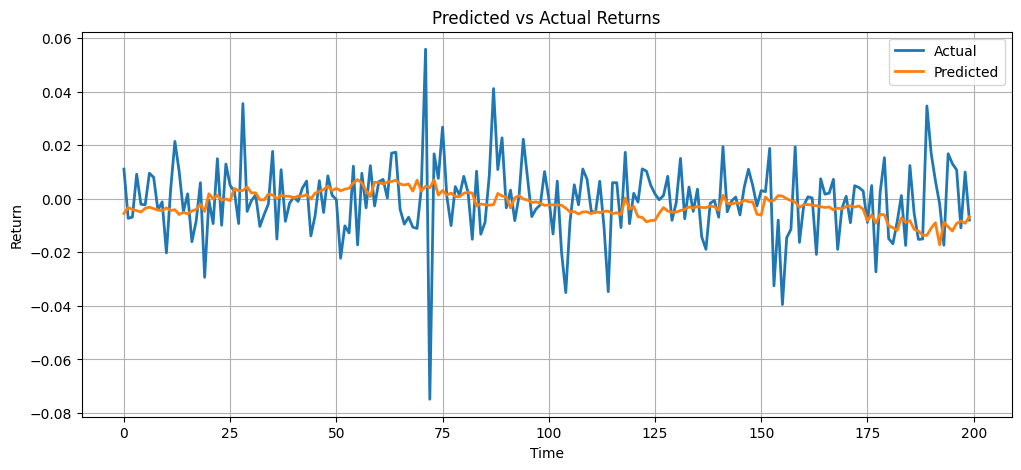

In [53]:

# Prediction vs Actual

plt.figure(figsize=(12,5))
plt.plot(
    targets[:200],
    label='Actual',
    linewidth=2
)
plt.plot(
    preds[:200],
    label='Predicted',
    linewidth=2
)

plt.title('Predicted vs Actual Returns')
plt.xlabel('Time')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.show()

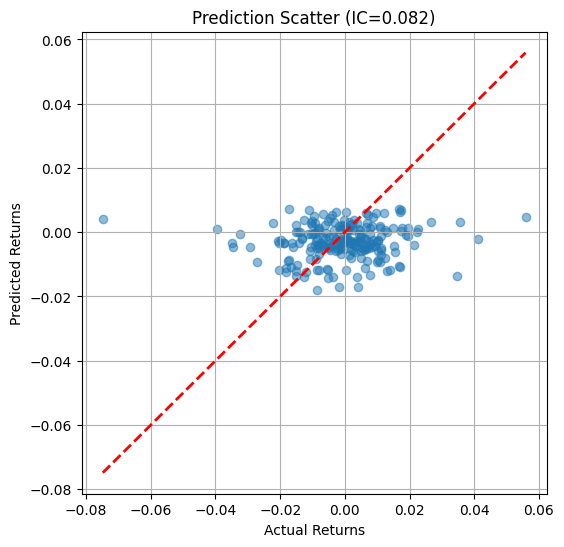

In [54]:

# Scatter plot

plt.figure(figsize=(6,6))

plt.scatter(
    targets,
    preds,
    alpha=0.5
)

# 45-degree reference line
min_v = min(targets.min(), preds.min())
max_v = max(targets.max(), preds.max())

plt.plot(
    [min_v, max_v],
    [min_v, max_v],
    'r--',
    linewidth=2
)

plt.xlabel('Actual Returns')

plt.ylabel('Predicted Returns')

plt.title(f'Prediction Scatter (IC={ic:.3f})')

plt.grid(True)

plt.show()

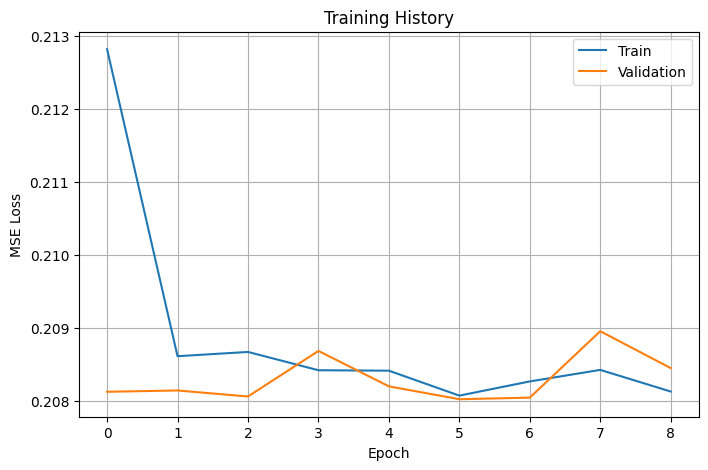

In [55]:

# Training history

plt.figure(figsize=(8,5))

plt.plot(
    history['train_loss'],
    label='Train'
)

plt.plot(
    history['val_loss'],
    label='Validation'
)

plt.xlabel('Epoch')

plt.ylabel('MSE Loss')

plt.title('Training History')

plt.legend()

plt.grid(True)

plt.show()

In [56]:

# Save predictions

pred_df = pd.DataFrame({
    'Actual': targets,
    'Predicted': preds
})

pred_df.to_csv(
    f'{RESULTS_PATH}/del3_predictions.csv',
    index=False
)

print('Predictions saved')

Predictions saved


#Ablation